In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from scimba_jax.linear_approximation.meshes.mesh_1d import Mesh1D
from scimba_jax.linear_approximation.quad.gauss_quad import UnitSquareTensorized
from scimba_jax.mapping.mapping import Mapping, InvertibleFunction

Scimba_jax uses device: [CudaDevice(id=0)]
Scimba_jax uses dtype: <class 'jax.numpy.float64'>


## Maillage 1D

In [2]:
# Créer une quadrature 1D avec ordre 2
quad_1d = UnitSquareTensorized(dim=1, order=2)

# Créer un mapping trivial (identité sur [0,1])
identity = InvertibleFunction(
    f=lambda x: x,      # f(x) = x
    f_inv=lambda y: y   # f^-1(y) = y
)
mapping = Mapping([identity])

# Créer le maillage 1D avec 10 cellules
mesh_1d = Mesh1D(
    dim=1,
    n_cells=400,
    ref_quad=quad_1d,
    mapping=mapping
)

print("✓ Maillage 1D créé !")
print(f"  - Dimension: {mesh_1d.dim}")
print(f"  - Nombre de cellules: {mesh_1d.n_cells}")
print(f"  - Nombre total de cellules: {mesh_1d.n_cells_total}")
print(f"  - Points de quadrature par cellule: {mesh_1d.n_gauss}")
print(f"  - Nombre de faces: {mesh_1d.n_faces}")

✓ Maillage 1D créé !
  - Dimension: 1
  - Nombre de cellules: 400
  - Nombre total de cellules: 400
  - Points de quadrature par cellule: 2
  - Nombre de faces: 401


In [3]:
# Récupérer les nœuds du maillage
mesh_nodes_logical = mesh_1d.n_i_faces / mesh_1d.n_cells  # [0, 1/10, 2/10, ..., 1]
x_complete = np.asarray(mesh_1d.mapping.local_mapping(mesh_nodes_logical))
N = len(x_complete) # Nombre total de nœuds

# Récupérer les points intérieurs (excluant les bords)
x_int = x_complete[1:-1]
N_int = len(x_int) # Nombre de nœuds intérieurs
h = x_complete[1] - x_complete[0]  # Pas d'espace (obtenu du maillage)

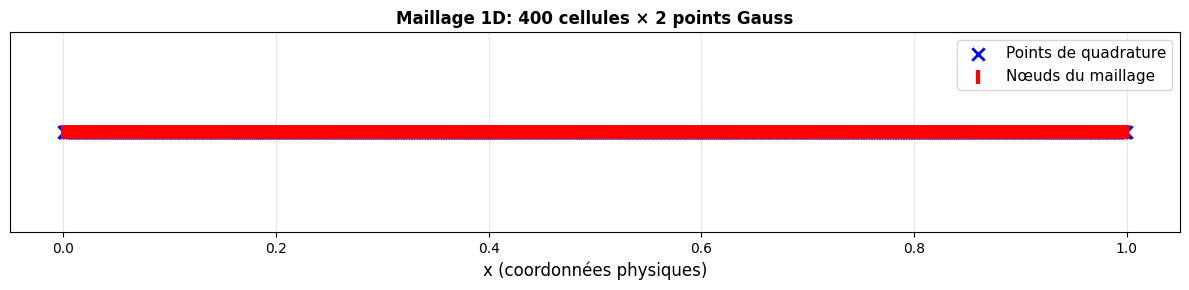

✓ Maillage 1D visualisé:
  • Nœuds: 401
  • Cellules: 400
  • Points Gauss/cellule: 2
  • Total points quadrature: 800


In [4]:
# Plot simplifié du mesh_1d
plt.close('all')  # Fermer toutes les figures précédentes
fig, ax = plt.subplots(figsize=(12, 3))

# Récupérer tous les points de quadrature via la classe
quad_points = mesh_1d.evaluate_mesh_points()  # shape: (n_cells, n_gauss, 1)
quad_points_flat = np.asarray(quad_points).flatten()

# Nœuds du maillage
mesh_nodes_logical = mesh_1d.n_i_faces / mesh_1d.n_cells
mesh_nodes_phys = np.asarray(mesh_1d.mapping.local_mapping(mesh_nodes_logical))

# Affichage
ax.scatter(quad_points_flat, np.zeros_like(quad_points_flat), s=80, c='blue', marker='x', linewidths=2, label='Points de quadrature', zorder=4)
ax.scatter(mesh_nodes_phys, np.zeros_like(mesh_nodes_phys), s=100, c='red', marker='|', linewidths=3, label='Nœuds du maillage', zorder=5)

ax.set_xlabel('x (coordonnées physiques)', fontsize=12)
ax.set_ylabel('')
ax.set_title(f'Maillage 1D: {mesh_1d.n_cells} cellules × {mesh_1d.n_gauss} points Gauss', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.1, 0.1])
ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"✓ Maillage 1D visualisé:")
print(f"  • Nœuds: {mesh_1d.n_faces}")
print(f"  • Cellules: {mesh_1d.n_cells}")
print(f"  • Points Gauss/cellule: {mesh_1d.n_gauss}")
print(f"  • Total points quadrature: {mesh_1d.n_cells * mesh_1d.n_gauss}")

## Problème non-linéaire 1D

**Problème :** Considérons maintenant le problème de Poisson 1D avec un terme quadratique paramétré par $\alpha > 0$ :

$$\left\{\begin{align*}
-u''(x)+\alpha u^2(x) &= f(x),\quad x\in(0,1) \\
u(0) = u(1) &= 0\end{align*}\right.$$

Pour la résolution numérique, on fixe **$\alpha = 5$**, puis on étudiera la sensibilité de la solution à ce paramètre.

On considère la solution analytique $$u(x,\alpha) = \alpha\sin(2 \pi x).$$

**Schéma DF :** On considère un schéma différences finies (centré d'ordre 2) sur un maillage uniforme : 

$$\left\{\begin{align*}
-u_{i+1}+2u_i-u_{i-1} + \alpha h^2 u_i^2 &= h^2f_i,\quad i=1,\ldots,N-1 \\
u_0 = u_N &= 0\end{align*}\right.$$ 

Ce système est **non-linéaire**, on utilise donc la **méthode de Newton-Raphson** pour le résoudre :

$$\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)} - J_F(\mathbf{u}^{(k)})^{-1} F(\mathbf{u}^{(k)})$$

où $F(\mathbf{u})$ est le résidu et $J_F$ sa Jacobienne.

In [5]:

def u_exact_nl(x, alpha):
    """Solution exacte du problème."""
    return alpha * jnp.sin(2 * jnp.pi * x)

def f_source_nl(x, alpha):
    """Fonction source f(x) correspondant à la solution exacte."""
    return (alpha**2 * jnp.sin(2 * jnp.pi * x) + (2 * jnp.pi)**2) * alpha * jnp.sin(2 * jnp.pi * x)

def add_bc(u_int):
    """Ajouter les conditions de Dirichlet (u=0 aux bords)."""
    return jnp.concatenate([jnp.array([0.0]), u_int, jnp.array([0.0])])

def F_nl(u_int, h, alpha, x_int):
    """Opérateur différentiel appliqué à u (intérieur uniquement)."""
    # Reconstruire u avec conditions de Dirichlet aux bords
    u = add_bc(u_int)
    # Laplacien par DF centré: -u''
    laplacian = -(u[2:] - 2*u[1:-1] + u[:-2]) / h**2
    # Terme non-linéaire: alpha*u^2
    nonlinear_term = alpha * u_int**2
    # Second membre f(x) - pour avoir une solution proche de sin(pi*x), on ajuste f
    f_rhs = f_source_nl(x_int, alpha)
    return laplacian + nonlinear_term - f_rhs


# Paramètres du problème non-linéaire
alpha_nl = 4  # Coefficient du terme non-linéaire

# Solution exacte pour vérification
u_ex_nl = u_exact_nl(x_complete, alpha_nl)

## Résolution du problème non-linéaire

### V0 : Résolution manuelle (non Matrix-Free)

Ici, on cherche à résoudre le problème en construisant la jacobienne avec `jax.jacobian` et on fait le Newton-Raphson "à la main".

In [6]:

# Méthode de Newton-Raphson (avec méthode de continuation)
alpha_start = 3.5
n_steps = 3
alpha_path = jnp.linspace(alpha_start, alpha_nl, n_steps)

u_nl_cont = jnp.zeros(N_int)
max_iter = 50
tol = 1e-8

jac_F = jax.jacobian(F_nl, argnums=0)
nb_iterations = []
for a in alpha_path:
    converge = False
    for k in range(max_iter):
        # Calculer le résidu
        F_k = F_nl(u_nl_cont, h, a, x_int)

        # Calculer la Jacobienne via JAX
        J_k = jac_F(u_nl_cont, h, a, x_int)
        
        # Résoudre le système linéaire: J * delta_u = -F
        delta_u = jnp.linalg.solve(J_k, -F_k)
        
        # Mise à jour
        u_nl_cont = u_nl_cont + delta_u
        
        # Critère de convergence
        residual_norm = jnp.linalg.norm(F_k)
        if residual_norm < tol:
            converge = True
            break
        # print("residual_norm =",residual_norm)
    nb_iterations.append(k)
    if not converge:
        print(f"⚠ Nombre maximum d'itérations atteint pour alpha = {a}")
        # print(f"  • Résidu final: {residual_norm:.6e}")

u_nl_cont_complete = add_bc(u_nl_cont)
print(f"✓ Problème non-linéaire résolu avec méthode de continuation:")
print("Nombre d'itérations par étape:", nb_iterations)

# Vérification
residual_lm = jnp.linalg.norm(F_nl(u_nl_cont, h, alpha_nl, x_int))
error_lm = jnp.sqrt(jnp.trapezoid((u_nl_cont_complete - u_ex_nl)**2, x_complete))

print(f"✓ LevenbergMarquardt + CG (jaxopt, matrix-free) :")
print(f"  • Résidu final : {residual_lm:.6e}")
print(f"  • Erreur L2    : {error_lm:.6e}")

⚠ Nombre maximum d'itérations atteint pour alpha = 3.75
✓ Problème non-linéaire résolu avec méthode de continuation:
Nombre d'itérations par étape: [8, 49, 5]
✓ LevenbergMarquardt + CG (jaxopt, matrix-free) :
  • Résidu final : 8.298439e-10
  • Erreur L2    : 4.643869e-04


### V1 : Utilisation de `jaxopt`

`jaxopt` fournit deux solveurs adaptés aux **moindres carrés non linéaires** :

| Solveur | Méthode | Solveur linéaire interne | Matrix-free ? |
|---------|---------|--------------------------|---------------|
| `GaussNewton` | Gauss-Newton | direct (par défaut) | **Non** |
| `LevenbergMarquardt` | Levenberg-Marquardt | `solve_cg` + `materialize_jac=False` | **Oui** |

Pour le Matrix-Free, l'idée est de ne **jamais former explicitement la Jacobienne** $J_F$. À la place, on utilise :
- le **JVP** de $F$ pour calculer $J_F \cdot v$ (produit matrice-vecteur)
- le **VJP** de $F$ pour calculer $J_F^T \cdot v$


**Interface :** `solver.run(init_params, *args)` où `*args` sont passés à `residual_fun(params, *args)`.

#### Résolution avec `GaussNewton` (non Matrix-Free)

GN résout à chaque itération :

$$(J^T J) \delta= -J^T F$$

**On applique aussi la méthode de continuation** car quand on est loin de la solution (ex: $u=0$ avec $\alpha=4$), $J^T J$ peut être mal conditionné et le pas $\delta$ est trop grand → divergence. GN n'a que des garanties de convergence locale (il faut déjà être près de la solution). La continuation contourne cela en commençant par un problème plus facile ($\alpha=3.5$) et en augmentant progressivement.

In [7]:
from jaxopt import GaussNewton

# GaussNewton minimise ||F(u)||^2 / 2
# residual_fun(params, *args) -> F_nl(u_int, h, alpha, x_int)
solver_gn = GaussNewton(residual_fun=F_nl, maxiter=50, tol=1e-8)

# Résolution pour alpha_nl (continuation comme avant pour converger)
alpha_start = 3.5
n_steps = 3
alpha_path = jnp.linspace(alpha_start, alpha_nl, n_steps)

u_gn = jnp.zeros(N_int)
for a in alpha_path:
    result = solver_gn.run(u_gn, h, a, x_int)
    u_gn = result.params

u_gn_complete = add_bc(u_gn)

# Vérification
residual_gn = jnp.linalg.norm(F_nl(u_gn, h, alpha_nl, x_int))
error_gn = jnp.sqrt(jnp.trapezoid((u_gn_complete - u_exact_nl(x_complete, alpha_nl))**2, x_complete))

print(f"✓ GaussNewton (jaxopt) :")
print(f"  • Résidu final : {residual_gn:.6e}")
print(f"  • Erreur L2    : {error_gn:.6e}")
# print(f"  • État : {result.state}")

✓ GaussNewton (jaxopt) :
  • Résidu final : 8.289304e-10
  • Erreur L2    : 4.643869e-04


#### Résolution avec `LevenbergMarquardt` + solveur linéaire CG (Matrix-Free)

LM résout à chaque itération :

$$(J^T J + \lambda I) \delta = -J^T F$$

**On applique pas la méthode de continuation** car le facteur d'amortissement $\lambda$ s'adapte automatiquement :

- $\lambda$ grand → pas $\delta$ petit dans la direction du gradient descendant (stable, même loin de la solution)

- $\lambda$ petit → pas de type Gauss-Newton (rapide près de la solution)

Si un pas échoue (i.e., le résidu augmente) → LM augmente $\lambda$. 

*C'est ce que confirme le résultat du notebook : damping_factor ≈ 4.3×10⁹ → LM a appliqué un amortissement énorme pour gérer le problème difficile.*

En résumé : la continuation fait manuellement ce que LM fait automatiquement via $\lambda$ — réduire la taille des pas quand on est loin de la solution. LM joue le rôle de son propre mécanisme de continuation interne

**La résolution est complètement Matrix-Free** car en passant `solver=solve_cg`, le solveur linéaire interne de LM utilise le *Gradient Conjugué* : il ne forme jamais $J^T J$ explicitement, mais calcule des produits matrice-vecteur via JVP/VJP.

In [8]:
from jaxopt import LevenbergMarquardt
from jaxopt.linear_solve import solve_cg

# LevenbergMarquardt avec CG comme solveur linéaire interne -> matrix-free
# Le solveur CG ne forme jamais J^T J : il utilise des JVP/VJP de F
solver_lm = LevenbergMarquardt(
    residual_fun=F_nl,
    solver=solve_cg,
    maxiter=50,
    tol=1e-8,
)

u_lm = jnp.zeros(N_int)
for a in alpha_path:
    result_lm = solver_lm.run(u_lm, h, a, x_int)
    u_lm = result_lm.params

u_lm_complete = add_bc(u_lm)

# Vérification
residual_lm = jnp.linalg.norm(F_nl(u_lm, h, alpha_nl, x_int))
error_lm = jnp.sqrt(jnp.trapezoid((u_lm_complete - u_exact_nl(x_complete, alpha_nl))**2, x_complete))

print(f"✓ LevenbergMarquardt + CG (jaxopt, matrix-free) :")
print(f"  • Résidu final : {residual_lm:.6e}")
print(f"  • Erreur L2    : {error_lm:.6e}")
# print(f"  • État : {result_lm.state}")
print(f"damping_factor : {result_lm.state.damping_factor:.6e}")

✓ LevenbergMarquardt + CG (jaxopt, matrix-free) :
  • Résidu final : 7.878968e-10
  • Erreur L2    : 4.643869e-04
damping_factor : 4.294967e+09


### Comparaison des trois approches

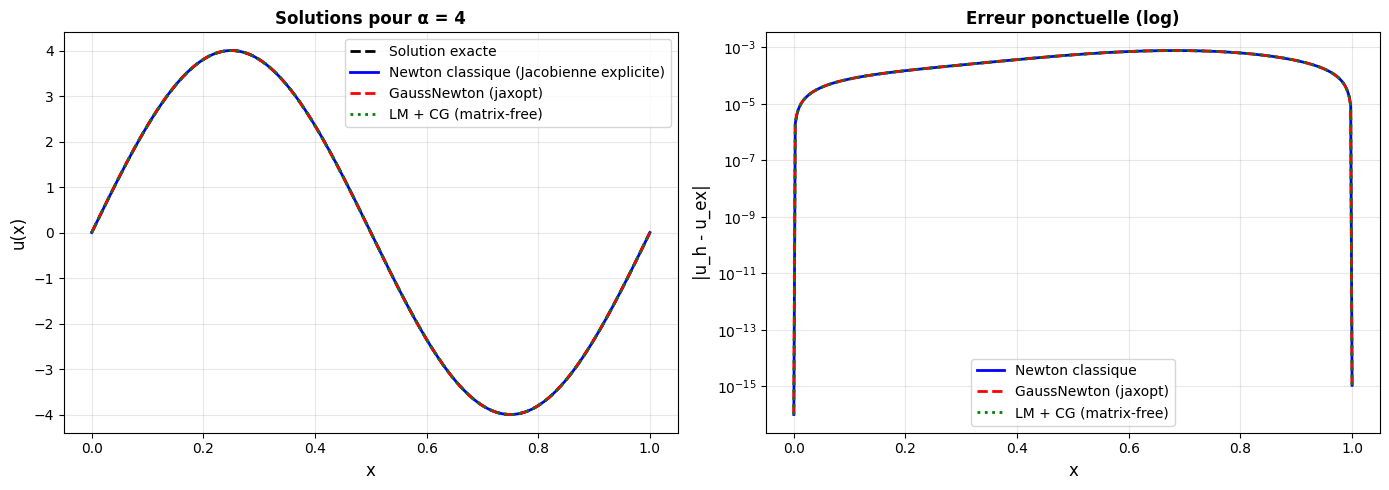

Méthode                                        Erreur L2          Résidu
------------------------------------------------------------------------
Newton classique (Jacobienne explicite)     4.643869e-04    8.298439e-10
GaussNewton (jaxopt)                        4.643869e-04    8.289304e-10
LM + CG - matrix-free (jaxopt)              4.643869e-04    7.878968e-10


In [9]:
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Solutions ---
ax = axes[0]
ax.plot(x_complete, u_ex_nl, 'k--', linewidth=2, label='Solution exacte')
ax.plot(x_complete, u_nl_cont_complete, 'b-', linewidth=2, label='Newton classique (Jacobienne explicite)')
ax.plot(x_complete, u_gn_complete, 'r--', linewidth=2, label='GaussNewton (jaxopt)')
ax.plot(x_complete, u_lm_complete, 'g:', linewidth=2, label='LM + CG (matrix-free)')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x)', fontsize=12)
ax.set_title(f'Solutions pour α = {alpha_nl}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Graphique 2 : Erreurs ponctuelles ---
ax = axes[1]
ax.semilogy(x_complete, jnp.abs(u_nl_cont_complete - u_ex_nl) + 1e-16, 'b-', linewidth=2, label='Newton classique')
ax.semilogy(x_complete, jnp.abs(u_gn_complete - u_ex_nl) + 1e-16, 'r--', linewidth=2, label='GaussNewton (jaxopt)')
ax.semilogy(x_complete, jnp.abs(u_lm_complete - u_ex_nl) + 1e-16, 'g:', linewidth=2, label='LM + CG (matrix-free)')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('|u_h - u_ex|', fontsize=12)
ax.set_title('Erreur ponctuelle (log)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Tableau récapitulatif ---
error_newton = jnp.sqrt(jnp.trapezoid((u_nl_cont_complete - u_ex_nl)**2, x_complete))
print(f"{'Méthode':<40} {'Erreur L2':>15} {'Résidu':>15}")
print("-" * 72)
print(f"{'Newton classique (Jacobienne explicite)':<40} {float(error_newton):>15.6e} {float(jnp.linalg.norm(F_nl(u_nl_cont, h, alpha_nl, x_int))):>15.6e}")
print(f"{'GaussNewton (jaxopt)':<40} {float(error_gn):>15.6e} {float(residual_gn):>15.6e}")
print(f"{'LM + CG - matrix-free (jaxopt)':<40} {float(error_lm):>15.6e} {float(residual_lm):>15.6e}")

### Dépendance à $\alpha$ : Calcul de la dérivée $\frac{\partial u}{\partial \alpha}$ avec `custom_vjp`

On cherche a mesurer la sensibilite de la solution au parametre $\alpha$ dans le cas non-lineaire. Le residu s'ecrit :

$$F(u,\alpha) = -u'' + \alpha u^2 - f(x,\alpha) = 0.$$

**Differentiation implicite :**

En derivant $F(u(\alpha),\alpha)=0$ par rapport a $\alpha$ :

$$\frac{\partial F}{\partial u}\,\frac{\partial u}{\partial \alpha} + \frac{\partial F}{\partial \alpha} = 0,$$

soit

$$\boxed{\frac{\partial u}{\partial \alpha} = -\left(\frac{\partial F}{\partial u}\right)^{-1}\frac{\partial F}{\partial \alpha}}.$$

Ici $\frac{\partial F}{\partial u}$ est la Jacobienne de Newton, et $\frac{\partial F}{\partial \alpha}$ se calcule automatiquement avec JAX.

**Implémentation avec `custom_vjp` :**

- **`solve_nl_fwd`** : resout le probleme non-lineaire (Newton) et sauvegarde $u$.
- **`solve_nl_bwd`** : resout un systeme lineaire avec la Jacobienne pour obtenir le VJP.

**Fonction de cout :**

$$J(\alpha)=\|u(\cdot,\alpha)\|_{L^2(0,1)}.$$

Pour la solution analytique $u(x,\alpha)=\alpha\sin(2\pi x)$, on a encore

$$J(\alpha)=\frac{\alpha}{\sqrt{2}},$$

et on utilisera en discret :

$$J_h(\alpha)=\sqrt{\frac{1}{N+1}\sum_{i=0}^{N} u_i(\alpha)^2}.$$

In [ ]:
def J_nl(alpha):
    """Norme L2 analytique de u pour le cas non-lineaire."""
    return alpha / jnp.sqrt(2)


def J_h_nl(u):
    """Norme L2 discrete pour un vecteur u complet (bords inclus)."""
    return jnp.sqrt(jnp.mean(u**2))

In [ ]:
def newton_solve_nl(alpha, h, x_int, max_iter=50, tol=1e-8):
    """Resolution non-lineaire par Newton pour un alpha donne."""
    u = jnp.zeros_like(x_int)
    jac_F = jax.jacobian(F_nl, argnums=0)

    for _ in range(max_iter):
        F_k = F_nl(u, h, alpha, x_int)
        J_k = jac_F(u, h, alpha, x_int)
        delta_u = jnp.linalg.solve(J_k, -F_k)
        u = u + delta_u
        if jnp.linalg.norm(F_k) < tol:
            break

    return u


@jax.custom_vjp
def solve_nonlinear_system(alpha, h, x_int):
    """Retourne u_int(alpha) en resolvant F(u, alpha) = 0."""
    return newton_solve_nl(alpha, h, x_int)


def solve_nl_fwd(alpha, h, x_int):
    """Forward pass: calcule u et sauvegarde les infos utiles."""
    u_int_sol = newton_solve_nl(alpha, h, x_int)
    return u_int_sol, (alpha, h, x_int, u_int_sol)


def solve_nl_bwd(res, g):
    """Backward pass: calcule le VJP via differentiation implicite."""
    alpha, h, x_int, u_int_sol = res

    # Jacobienne en u: dF/du
    J_u = jax.jacobian(F_nl, argnums=0)(u_int_sol, h, alpha, x_int)

    # Derivee par rapport a alpha: dF/dalpha (vecteur)
    dF_dalpha = jax.jacobian(F_nl, argnums=2)(u_int_sol, h, alpha, x_int)

    # du/dalpha = - J_u^{-1} * dF/dalpha
    du_dalpha = -jnp.linalg.solve(J_u, dF_dalpha)

    # VJP: dL/dalpha = g^T * du/dalpha
    vjp_alpha = jnp.dot(g, du_dalpha)

    return (vjp_alpha, None, None)


solve_nonlinear_system.defvjp(solve_nl_fwd, solve_nl_bwd)

### Dépendance à $\alpha$ : Différentiation implicite avec jaxopt

En théorie, jaxopt gère la différentiation implicite en interne. En pratique, on a constaté deux limitations :

- `jax.jacobian` (utilise `vmap(vjp)`) → gradient = 0 silencieusement
- `jax.jvp` (mode forward) → `TypeError` : interdit sur `custom_vjp`
- `jax.grad` sur scalaire → gradient ~0 : jaxopt ne propage pas le gradient vers les `*args` (comme `alpha`), seulement vers `init_params`

**Solution :** envelopper chaque solveur jaxopt avec un `custom_vjp` manuel. Le **forward** utilise jaxopt, le **backward** applique l'IFT :
$$\frac{\partial u}{\partial \alpha} = -\left(\frac{\partial F}{\partial u}\right)^{-1}\frac{\partial F}{\partial \alpha}$$

In [ ]:
# --- Limitation de jaxopt pour la différentiation ---
#
# jaxopt propage le gradient via custom_vjp en interne, mais UNIQUEMENT par rapport
# à init_params, pas par rapport aux *args (comme alpha ici).
# jax.grad(Jh_gn) donne ~0 pour alpha, jax.jvp est interdit sur custom_vjp.
#
# Solution : envelopper chaque solveur jaxopt avec notre propre custom_vjp.
# Forward  : résolution par jaxopt (GaussNewton ou LM+CG)
# Backward : différentiation implicite (IFT), identique au pt2

@jax.custom_vjp
def solve_gn_alpha(alpha):
    """Forward : GaussNewton (jaxopt)."""
    result = solver_gn.run(jnp.zeros(N_int), h, alpha, x_int)
    return result.params

def _gn_fwd(alpha):
    u = solve_gn_alpha(alpha)
    return u, (alpha, u)

def _gn_bwd(res, g):
    alpha, u_sol = res
    J_u    = jax.jacobian(F_nl, argnums=0)(u_sol, h, alpha, x_int)
    dF_da  = jax.jacobian(F_nl, argnums=2)(u_sol, h, alpha, x_int)
    vjp_alpha = jnp.dot(g, -jnp.linalg.solve(J_u, dF_da))
    return (vjp_alpha,)

solve_gn_alpha.defvjp(_gn_fwd, _gn_bwd)


@jax.custom_vjp
def solve_lm_alpha(alpha):
    """Forward : LevenbergMarquardt + CG (jaxopt, matrix-free)."""
    result = solver_lm.run(jnp.zeros(N_int), h, alpha, x_int)
    return result.params

def _lm_fwd(alpha):
    u = solve_lm_alpha(alpha)
    return u, (alpha, u)

def _lm_bwd(res, g):
    alpha, u_sol = res
    J_u    = jax.jacobian(F_nl, argnums=0)(u_sol, h, alpha, x_int)
    dF_da  = jax.jacobian(F_nl, argnums=2)(u_sol, h, alpha, x_int)
    vjp_alpha = jnp.dot(g, -jnp.linalg.solve(J_u, dF_da))
    return (vjp_alpha,)

solve_lm_alpha.defvjp(_lm_fwd, _lm_bwd)


# Fonctionnelles scalaires J_h(u(alpha)) pour jax.grad
def Jh_gn(alpha):
    u = solve_gn_alpha(alpha)
    return J_h_nl(add_bc(u))

def Jh_lm(alpha):
    u = solve_lm_alpha(alpha)
    return J_h_nl(add_bc(u))

def Jh_ref(alpha):
    u = solve_nonlinear_system(alpha, h, x_int)
    return J_h_nl(add_bc(u))

grad_gn_fn  = jax.grad(Jh_gn)
grad_lm_fn  = jax.grad(Jh_lm)
grad_ref_fn = jax.grad(Jh_ref)

# Vérification
exact_grad = 1.0 / jnp.sqrt(2.0)
alpha_test_values = jnp.array([1.0, 2.0, 3.0])
print(f"{'alpha':<8} {'dJh/dalpha  GN':>18} {'dJh/dalpha  LM+CG':>20} {'dJh/dalpha  ref':>18} {'exact':>10}")
print("-" * 78)
for a in alpha_test_values:
    print(f"{float(a):<8.1f} {float(grad_gn_fn(a)):>18.6e} {float(grad_lm_fn(a)):>20.6e} {float(grad_ref_fn(a)):>18.6e} {float(exact_grad):>10.6f}")

alpha        dJh/dalpha  GN    dJh/dalpha  LM+CG    dJh/dalpha  ref      exact
------------------------------------------------------------------------------
1.0            7.062394e-01         7.062394e-01       7.062394e-01   0.707107
2.0            7.062459e-01         7.062459e-01       7.062459e-01   0.707107
3.0            7.063177e-01         7.063177e-01       7.063177e-01   0.707107


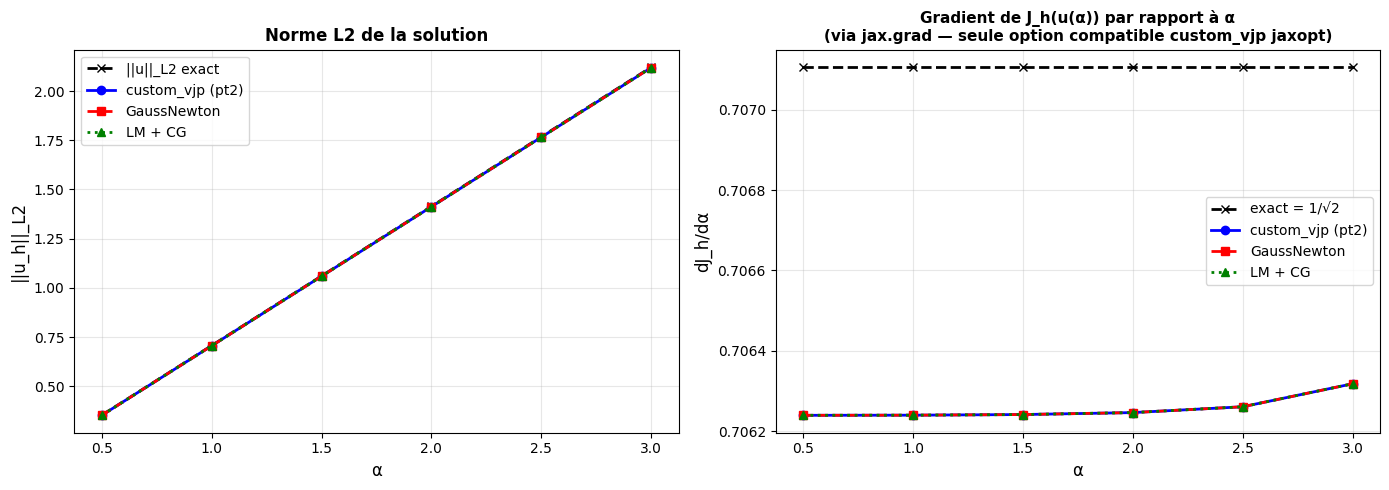

✓ Comparaison sensibilité (dJ_h/dalpha) : custom_vjp (pt2) vs jaxopt (GN et LM+CG)


In [ ]:
alpha_values_nl = jnp.linspace(0.5, 3.0, 6)

norms_gn  = []
norms_lm  = []
norms_ref = []
grads_gn  = []
grads_lm  = []
grads_ref = []

for a in alpha_values_nl:
    # Solutions
    u_int_gn  = solve_gn_alpha(a)
    u_int_lm  = solve_lm_alpha(a)
    u_int_ref = solve_nonlinear_system(a, h, x_int)

    norms_gn.append(J_h_nl(add_bc(u_int_gn)))
    norms_lm.append(J_h_nl(add_bc(u_int_lm)))
    norms_ref.append(J_h_nl(add_bc(u_int_ref)))

    # Gradients via jax.grad (scalaire) — seule option compatible avec custom_vjp de jaxopt
    grads_gn.append(grad_gn_fn(a))
    grads_lm.append(grad_lm_fn(a))
    grads_ref.append(grad_ref_fn(a))

exact_norms = jnp.array([J_nl(a) for a in alpha_values_nl])
exact_grads = jnp.full(len(alpha_values_nl), 1.0 / jnp.sqrt(2.0))

plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Normes
ax1.plot(alpha_values_nl, exact_norms, 'k--', linewidth=2, label='||u||_L2 exact', marker='x')
ax1.plot(alpha_values_nl, norms_ref,   'b-',  linewidth=2, label='custom_vjp (pt2)', marker='o')
ax1.plot(alpha_values_nl, norms_gn,    'r--', linewidth=2, label='GaussNewton',       marker='s')
ax1.plot(alpha_values_nl, norms_lm,    'g:',  linewidth=2, label='LM + CG',           marker='^')
ax1.set_xlabel('α', fontsize=12)
ax1.set_ylabel('||u_h||_L2', fontsize=12)
ax1.set_title('Norme L2 de la solution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gradients dJ_h/dalpha
ax2.plot(alpha_values_nl, exact_grads, 'k--', linewidth=2, label='exact = 1/√2', marker='x')
ax2.plot(alpha_values_nl, grads_ref,   'b-',  linewidth=2, label='custom_vjp (pt2)', marker='o')
ax2.plot(alpha_values_nl, grads_gn,    'r--', linewidth=2, label='GaussNewton',       marker='s')
ax2.plot(alpha_values_nl, grads_lm,    'g:',  linewidth=2, label='LM + CG',           marker='^')
ax2.set_xlabel('α', fontsize=12)
ax2.set_ylabel('dJ_h/dα', fontsize=12)
ax2.set_title('Gradient de J_h(u(α)) par rapport à α\n(via jax.grad — seule option compatible custom_vjp jaxopt)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Comparaison sensibilité (dJ_h/dalpha) : custom_vjp (pt2) vs jaxopt (GN et LM+CG)")